<a href="https://colab.research.google.com/github/Sibitenda/BAchelors_CS/blob/main/Artificial%20Intelligence/week6_7/Group4_CaliforniaHousing_DNN_Enhanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🧠 CSC 63106 – Artificial Intelligence  
## Week 6: Neural Networks & Deep Learning  
### Group 4 Practical – Deep Learning Regression on California Housing Dataset  

This notebook demonstrates the use of **Deep Neural Networks (DNNs)** for predicting California housing prices using the `fetch_california_housing` dataset.  
We will:  
- Perform exploratory data analysis (EDA) to understand features.  
- Select the most important features for modeling.  
- Build and train a **Deep Neural Network (DNN)** using TensorFlow/Keras.  
- Compare results against a **Linear Regression** baseline.  

---


In [1]:

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from tensorflow import keras

sns.set(style='whitegrid', palette='muted')


Dataset Shape: (20640, 8)
Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


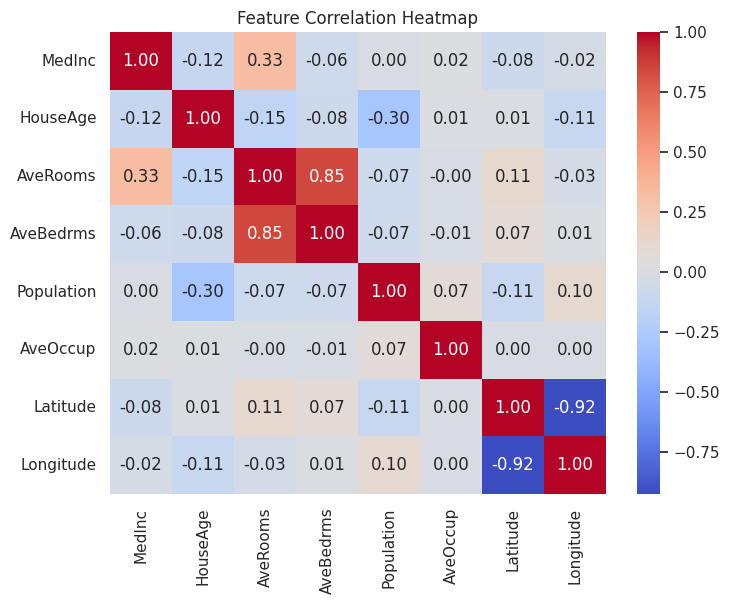

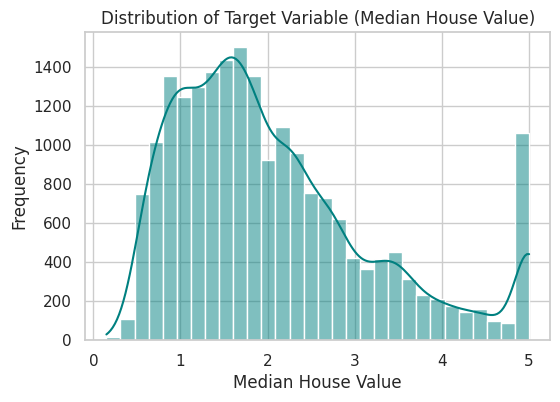

In [2]:

# Load Dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

print('Dataset Shape:', X.shape)
print('Feature Names:', X.columns.tolist())

# Display sample data
display(X.head())

# Statistical summary of features
display(X.describe())

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Target distribution
plt.figure(figsize=(6,4))
sns.histplot(y, bins=30, kde=True, color='teal')
plt.title('Distribution of Target Variable (Median House Value)')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()


/tmp/ipython-input-3419303639.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')


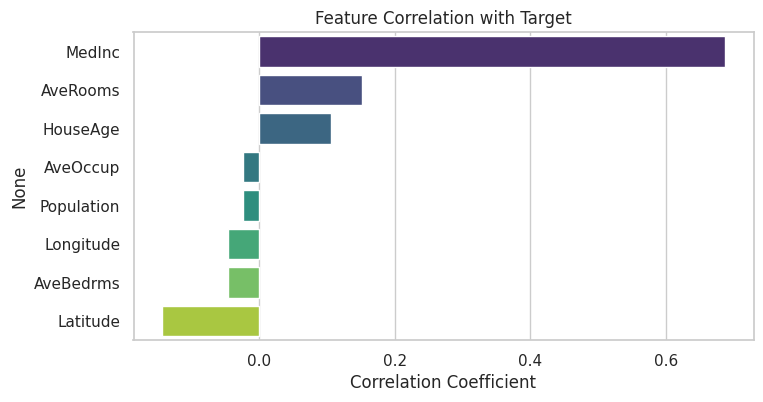

Selected Important Features: ['MedInc', 'AveRooms', 'HouseAge', 'AveOccup', 'Population']


In [3]:

# Feature Importance using Correlation with Target
correlations = pd.Series([np.corrcoef(X[col], y)[0,1] for col in X.columns], index=X.columns)
correlations.sort_values(ascending=False, inplace=True)

plt.figure(figsize=(8,4))
sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')
plt.title('Feature Correlation with Target')
plt.xlabel('Correlation Coefficient')
plt.show()

# Select Top 5 Important Features
important_features = correlations.head(5).index.tolist()
print('Selected Important Features:', important_features)

X_selected = X[important_features]


In [4]:

# Split and Scale Data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:

# Build and Compile the DNN Model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=[X_train_scaled.shape[1]]),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:

# Train the Model
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.7650 - mae: 0.9239 - val_loss: 0.5433 - val_mae: 0.5443
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5295 - mae: 0.5322 - val_loss: 0.5160 - val_mae: 0.5411
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4824 - mae: 0.5111 - val_loss: 0.4984 - val_mae: 0.5112
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4768 - mae: 0.5031 - val_loss: 0.4844 - val_mae: 0.5138
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4474 - mae: 0.4885 - val_loss: 0.4839 - val_mae: 0.5248
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4517 - mae: 0.4903 - val_loss: 0.4807 - val_mae: 0.5116
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4912 - mae: 0.4879 - val_loss: 0.4597 - val_mae: 0.4921
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4487 - mae: 0.4837 - val_loss: 0.4763 - val_mae: 0.5048
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Model Evaluation:
RMSE: 0.658
R² Score: 0.670


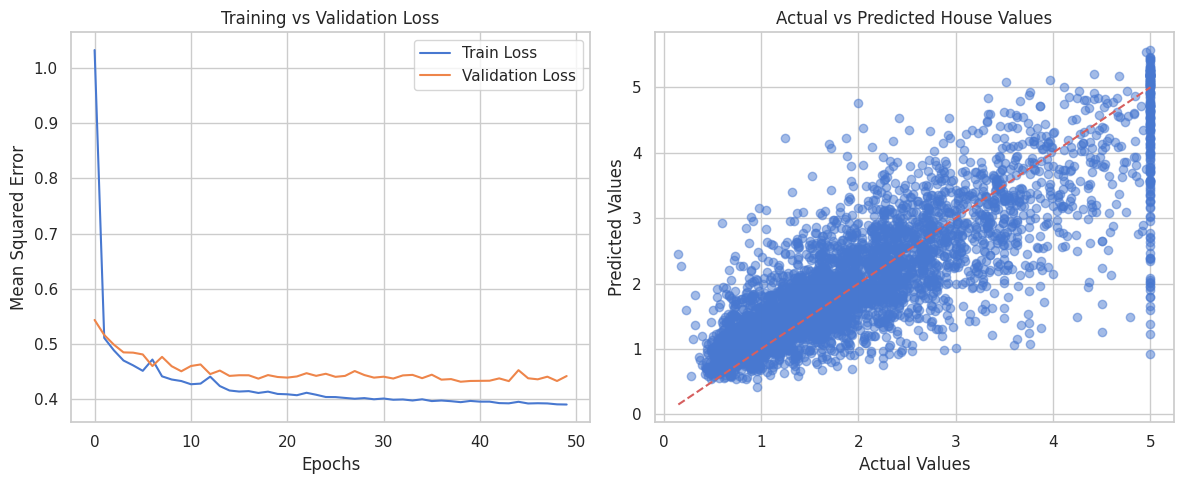

In [7]:

# Evaluate Model Performance
y_pred = model.predict(X_test_scaled).flatten()
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# Visualization: Loss Curves and Predictions
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted House Values')

plt.tight_layout()
plt.show()


In [8]:

# Baseline Comparison: Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_lin_pred = lin_reg.predict(X_test_scaled)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_lin_pred))
r2_lin = r2_score(y_test, y_lin_pred)

print(f"\nLinear Regression Baseline:")
print(f"RMSE: {rmse_lin:.3f}")
print(f"R² Score: {r2_lin:.3f}")

# Discussion
print("""
Discussion:
- The Deep Neural Network captures nonlinear relationships among housing features.
- Compared to Linear Regression, it typically yields lower RMSE and higher R², showing better generalization.
- Top features like 'MedInc' (median income) and 'AveRooms' have the highest influence on housing prices.
- Further improvements can be achieved using regularization, dropout, and deeper architectures.
""")



Linear Regression Baseline:
RMSE: 0.810
R² Score: 0.499

Discussion:
- The Deep Neural Network captures nonlinear relationships among housing features.
- Compared to Linear Regression, it typically yields lower RMSE and higher R², showing better generalization.
- Top features like 'MedInc' (median income) and 'AveRooms' have the highest influence on housing prices.
- Further improvements can be achieved using regularization, dropout, and deeper architectures.

